In [3]:
# ── Imports ────────────────────────────────────────────────────

import yfinance as yf       # données BTC depuis Yahoo Finance
import pandas as pd         
import numpy as np          
import matplotlib.pyplot as plt  #

# Option d'affichage
pd.set_option("display.max_columns", None)  
# affiche TOUTES les colonnes du DataFrame sans les tronquer

plt.style.use("dark_background")  
# thème sombre pour les graphiques — plus lisible pour la finance

print(" Imports OK")

 Imports OK


In [4]:
# ── Téléchargement des données ─────────────────────────────────

ticker = yf.Ticker("BTC-USD")
# yf.Ticker() crée un objet qui représente un actif financier
# "BTC-USD" = btc en dollar americain

df = ticker.history(
    start="2020-01-01",   # on part de 2020 
    end="2024-12-31",     # fin de période
    interval="1d"         # "1d" = une bougie par jour (bougie = un laps de temps qu'on veut traiter)
)

# On garde uniquement les colonnes utiles
df = df[["Open", "High", "Low", "Close", "Volume"]]
# Open   = prix à l'ouverture de la journée
# High   = prix le plus haut de la journée
# Low    = prix le plus bas de la journée
# Close  = prix à la clôture ← le plus important pour notre modèle
# Volume = quantité de BTC échangée ce jour-là

# Supprime les éventuelles lignes vides
df.dropna(inplace=True)
# inplace=True = modifie df directement sans créer une copie

print(f" {len(df)} jours de données chargées")
print(f" Du {df.index[0].date()} au {df.index[-1].date()}")
print("\n── Aperçu des 5 premières lignes ──")
df.head()

 1826 jours de données chargées
 Du 2020-01-01 au 2024-12-30

── Aperçu des 5 premières lignes ──


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-01 00:00:00+00:00,7194.892090,7254.330566,7174.944336,7200.174316,18565664997
2020-01-02 00:00:00+00:00,7202.551270,7212.155273,6935.270020,6985.470215,20802083465
2020-01-03 00:00:00+00:00,6984.428711,7413.715332,6914.996094,7344.884277,28111481032
2020-01-04 00:00:00+00:00,7345.375488,7427.385742,7309.514160,7410.656738,18444271275
2020-01-05 00:00:00+00:00,7410.451660,7544.497070,7400.535645,7411.317383,19725074095


In [6]:
# ── Statistiques descriptives ──────────────────────────────────

print("── Dimensions du DataFrame ──")
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")
# (nb_lignes, nb_colonnes)

print("\n── Types de données ──")
print(df.dtypes)
# float64 (nombres décimaux)

print("\n── Valeurs manquantes ──")
print(df.isnull().sum())
# .isnull() détecte les NaN 
# .sum() les compte par colonne

print("\n── Statistiques descriptives ──")
df.describe()
# count,mean,std(ecart-type), min/max, quartiles

── Dimensions du DataFrame ──
Lignes : 1826 | Colonnes : 5

── Types de données ──
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

── Valeurs manquantes ──
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

── Statistiques descriptives ──


,Open,High,Low,Close,Volume
count,1826.000000,1826.000000,1826.000000,1826.000000,1.826000e+03
mean,36241.794550,37039.012576,35414.325420,36286.084530,3.317299e+10
std,21055.200227,21523.049921,20573.353305,21083.215858,1.951953e+10
min,5002.578125,5331.833984,4106.980957,4970.788086,5.331173e+09
25%,19583.862305,20114.195801,19238.673340,19618.505859,2.060398e+10
50%,32134.140625,33309.777344,30855.880859,32156.772461,2.992437e+10
75%,50646.193359,51861.505859,49046.175781,50685.168945,4.016635e+10
max,106147.296875,108268.445312,105291.734375,106140.601562,3.509679e+11


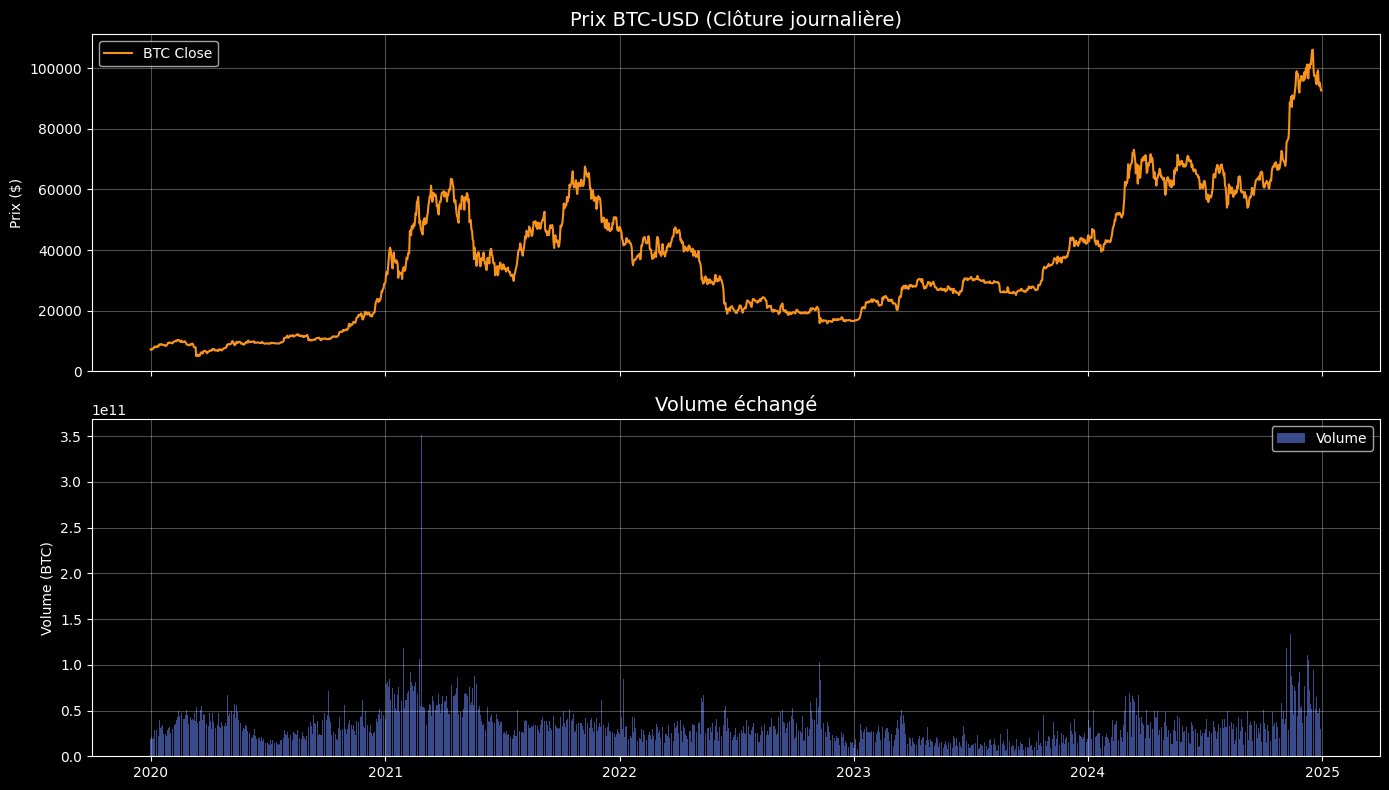

Graphique sauvegardé !


In [7]:
# ── Visualisation ──────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
# fig = la figure globale (la "feuille")
# axes = tableau de 2 graphiques empilés verticalement
# figsize=(14, 8) = largeur 14, hauteur 8 (en pouces)
# sharex=True = les deux graphiques partagent le même axe X (les dates)

# ── Graphique 1 : Prix de clôture ─────────────────────────────
axes[0].plot(
    df.index,        # axe X = les dates
    df["Close"],     # axe Y = prix de clôture
    color="#F7931A", # orange Bitcoin
    linewidth=1.5,
    label="BTC Close"
)
axes[0].set_title("Prix BTC-USD (Clôture journalière)", fontsize=14)
axes[0].set_ylabel("Prix ($)")
axes[0].legend()
axes[0].grid(alpha=0.3)  # grille légère, alpha=opacité

# ── Graphique 2 : Volume ───────────────────────────────────────
axes[1].bar(
    df.index,
    df["Volume"],
    color="#627EEA",  # bleu Ethereum (contraste sympa)
    alpha=0.6,        # légère transparence
    label="Volume"
)
axes[1].set_title("Volume échangé", fontsize=14)
axes[1].set_ylabel("Volume (BTC)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
# pour eviter le chevauchement des graphiques

plt.savefig("../data/btc_overview.png", dpi=150)
# sauvegarde l'image dans le dossier data/ avec une bonne résolution


plt.show()
print("Graphique sauvegardé !")

In [9]:
# ── Rendements journaliers ─────────────────────────────────────
#coté finances

df["returns"] = df["Close"].pct_change()
# variation en % entre chaque jour
# ex: Close J-1 = 40 000$, Close J = 42 000$ → return = +5%

df["log_returns"] = np.log(df["Close"] / df["Close"].shift(1))
# les rendements logarithmiques
# shift(1) = décale la colonne d'une ligne vers le bas
# c'est independant de la collone pourcentage qu'on rajoute 
#la on on divise le prix d'ajd sur celui d'hier et on le passe au logarithme pour representer correctement la perte ou le gain
# si je perd ajd 50% et que demain je gagne 50% je ne suis pas a zero en benef , et ça se represente tres bien en log contrairement au %

# inverse de log(x) est pow(10,x) 

# Supprime la première ligne qui contient NaN
df.dropna(inplace=True)

print(f"Rendement moyen journalier : {df['returns'].mean()*100:.2f}%")
print(f"Rendement max en 1 jour    : {df['returns'].max()*100:.2f}%")
print(f"Rendement min en 1 jour    : {df['returns'].min()*100:.2f}%")
print(f"Volatilité (std)           : {df['returns'].std()*100:.2f}%")

# ── Sauvegarde du DataFrame enrichi ───────────────────────────
df.to_csv("../data/btc_raw.csv")
print(" Données sauvegardées dans le dossier data")

Rendement moyen journalier : 0.20%
Rendement max en 1 jour    : 18.75%
Rendement min en 1 jour    : -37.17%
Volatilité (std)           : 3.36%
 Données sauvegardées dans le dossier data


+0.20% en moy sur 5 ans ça donne:
    Résultat final = (1 + rendement_journalier(%*100)) ^ nombre_de_jours
    (1 + 0.002) ^ (365*5) = 1.002 ^ 1826 ≈ 37
    le prix s'est multiplié par 37 , mais ce calcul ne prend pas en compte les chutes et hausses su btc

    pour savoir le coeff exacte , il faut diviser le prix de depart(janvier 2020) sur le pris d'arrivée (decembre 2024)

    Prix départ  (jan 2020) :   7 200$
    Prix arrivée (dec 2024) : 106 000$   ==========>   106 000 / 7 200 ≈ 14.7

    le prix s'est réelement multiplié par x14.7 

   

gain 18,75% en une journée probablement pendant la hausse de fin 2024 

perte de 37.17% en une journée probablement pendant le crash covid 

La volatilité — l'écart-type:
    C'est à quel point chaque jour s'éloigne de la moyenne 
    fomule : √( Σ(écart²) ÷ N ) racine de la somme des ecarte lévés au carré divisé sur N_total
